In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [5]:
from google.colab import files
uploaded = files.upload()

Saving career_students.csv to career_students (1).csv


In [6]:
data = pd.read_csv("/content/career_students.csv")

In [7]:
X = data.drop("Future Career", axis=1)
y = data["Future Career"]

In [8]:
le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
X = data.drop("Future Career", axis=1)
X = X.drop(columns=['Student ID', 'Name'])
object_columns = X.select_dtypes(include='object').columns
for col in object_columns:
    le_X = LabelEncoder()
    X[col] = le_X.fit_transform(X[col])
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1, validation_data=(X_test, y_test))

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.0417 - loss: 3.3972 - val_accuracy: 0.1667 - val_loss: 3.2967
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2014 - loss: 3.2190 - val_accuracy: 0.2500 - val_loss: 3.1628
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2500 - loss: 3.0410 - val_accuracy: 0.2778 - val_loss: 3.0165
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2708 - loss: 2.8416 - val_accuracy: 0.3056 - val_loss: 2.8672
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3472 - loss: 2.6140 - val_accuracy: 0.3611 - val_loss: 2.7076
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4653 - loss: 2.3937 - val_accuracy: 0.3611 - val_loss: 2.5518
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5139 - loss: 2.1807 - val_accuracy: 0.3611 - val_loss: 2.4658
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5556 - loss: 1.9924 - val_accuracy: 0.3611 - va

In [14]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


In [15]:
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

In [16]:
print("\n=== SAMPLE PREDICTIONS ===")
for i in range(5):
    print("Predicted:", y_pred_labels[i])
    print("Actual   :", y_test_labels[i])
    print("------")


=== SAMPLE PREDICTIONS ===
Predicted: Mobile App Developer
Actual   : Mobile App Developer
------
Predicted: Software Engineer
Actual   : Mobile App Developer
------
Predicted: Database Administrator
Actual   : Mobile App Developer
------
Predicted: Information Security Analyst
Actual   : Database Administrator
------
Predicted: NLP Research Scientist
Actual   : AI Researcher
------


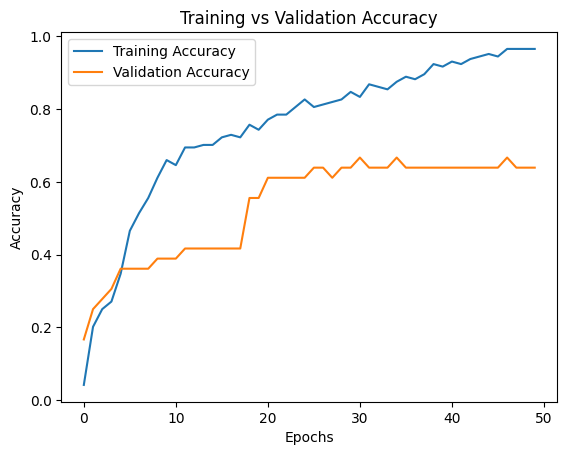

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [18]:
print("\n=== TEST CASES ===")


test_students = np.array([

    [1, 21, 3.5, 0, 1, 0, 1, 0, 1], # Student 1 (example preprocessed values)
    [0, 20, 3.2, 1, 0, 1, 0, 1, 0], # Student 2 (example preprocessed values)
    [1, 22, 3.8, 1, 1, 1, 1, 0, 0]  # Student 3 (example preprocessed values)
])


actual_feature_names = data.drop(columns=['Student ID', 'Name', 'Future Career']).columns.tolist()


test_students_df = pd.DataFrame(test_students, columns=actual_feature_names)
test_students_scaled = scaler.transform(test_students_df)
predictions = model.predict(test_students_scaled)
predicted_classes = np.argmax(predictions, axis=1)
predicted_careers = le.inverse_transform(predicted_classes)
for i, career in enumerate(predicted_careers):
    print(f"Student {i+1} Recommended Career: {career}")


=== TEST CASES ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Student 1 Recommended Career: Graphics Programmer
Student 2 Recommended Career: Cloud Solutions Architect
Student 3 Recommended Career: Cloud Solutions Architect


In [19]:
print("\n=== MODEL EVALUATION ===")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


=== MODEL EVALUATION ===
Accuracy: 0.6388888888888888

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           3       0.83      1.00      0.91         5
           5       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       0.33      0.50      0.40         2
          11       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          14       0.50      1.00      0.67         1
          16       0.50      1.00      0.67         1
          17       0.00      0.00      0.00         1
          18       0.50      1.00      0.67         2
          19       0.00      0.00      0.00         1
          20       1.00      0.50      0.67         2
          22       1.00      0.50      0.67        10
          24       0.00      0.00      0.00         0
  